<div style="text-align: center;">
<h1> Pre-processing multiomics benchmark </h1>    
</div>

The aim of this dataset is to pre-process the simulated dataset for direct multiROMA usage. The steps include : importing the data, quality checks, reformatting and generation of gene sets. The final dataset is saved as a mudata object, and a matching gene set is generated and saved as well. 

### Imports

In [1]:
import mudata
mudata.set_options(pull_on_update=False)
import muon as mu
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from multiroma_.utils import multiindex_df_to_mudata_extended 
from multiroma_.preprocessing import transcri_qc, proteomics_qc
from inmoose.pycombat import pycombat_norm

/opt/anaconda3/envs/ROMA_proj/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


We start by importing the raw dataset, and extracting the matrices separately. It is also possible to inspect the mudata object and correct anything deemed relevant. 

In [2]:
data = mu.read_h5mu("datasets/Simulation_dataset/simulated_ms_proteomics_bulk_dia 1.h5mu")
data

MuData object with n_obs × n_vars = 100 × 1600
  2 modalities
    rna:	100 x 1000
      obs:	'cell_id', 'cell_type', 'batch'
      uns:	'active_pathways', 'inactive_pathways', 'pathway_rankings_per_cell_type', 'pathways', 'resolution'
      obsm:	'pathway_activity_truth', 'pathway_activity_truth_binary', 'pathway_activity_truth_ranked'
    ms_prot:	100 x 600
      obs:	'cell_id', 'cell_type', 'batch'
      var:	'source_gene', 'gene_index_in_rna', 'detectability_score'
      uns:	'data_type', 'missing_value', 'ms_mode', 'resolution'

In [3]:
prot_df=pd.DataFrame(data["ms_prot"].X, index=data["ms_prot"].obs["cell_id"], columns=data["ms_prot"].var["source_gene"])
prot_df

source_gene,GENE0001,GENE0002,GENE0003,GENE0004,GENE0005,GENE0006,GENE0007,GENE0008,GENE0009,GENE0010,...,GENE0978,GENE0980,GENE0981,GENE0984,GENE0985,GENE0993,GENE0995,GENE0996,GENE0997,GENE0998
cell_id,,,,,,,,,,,,,,,,,,,,,
batch1_CellType_1_sample0000,15.395514,14.179483,14.116085,14.157969,16.505259,14.513043,15.040704,16.220430,13.369759,13.490480,...,15.692969,NaN,13.931174,14.547016,15.773411,14.335384,12.868075,NaN,14.117914,13.403585
batch1_CellType_1_sample0001,14.655165,14.122156,14.673669,13.860523,17.157558,14.887857,15.367029,16.593422,13.354800,13.293138,...,15.069986,14.233890,12.454364,14.404501,15.192993,14.293482,NaN,NaN,14.155516,NaN
batch1_CellType_1_sample0002,15.471313,12.750866,13.899436,13.343516,16.354969,14.230563,14.676167,16.254576,14.234394,13.227298,...,15.886830,15.361200,13.510928,14.168367,15.408723,13.753978,NaN,NaN,14.520604,13.292602
batch1_CellType_1_sample0003,14.719530,15.114807,14.139380,13.984716,16.704891,14.902282,14.754955,16.161562,13.564795,13.360991,...,NaN,13.864791,13.687153,14.538136,15.784092,13.571823,11.822750,11.092446,14.385621,13.338772
batch1_CellType_1_sample0004,15.262705,14.076678,13.611950,13.669152,17.209587,14.902835,NaN,16.089396,14.326101,13.088834,...,15.797982,14.600163,14.491558,14.312213,15.424625,14.255911,12.289118,NaN,13.642570,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
batch2_CellType_5_sample0005,14.077635,13.062140,13.764499,11.709516,14.461390,13.033975,14.051123,14.033291,11.876596,11.319256,...,13.021938,12.725555,12.230124,13.600908,14.062998,12.351682,NaN,10.385689,12.228260,11.591771
batch2_CellType_5_sample0006,13.839046,12.838821,13.516591,NaN,13.752131,13.532655,13.499859,14.246455,12.873116,11.201846,...,12.770548,12.865991,NaN,13.173529,13.004222,11.873837,NaN,NaN,NaN,NaN
batch2_CellType_5_sample0007,13.441296,12.752175,14.171851,12.131196,13.858584,13.330289,13.212894,14.095135,12.341082,11.206563,...,12.916662,13.725251,12.277160,13.570656,14.497766,11.522347,NaN,NaN,12.728573,11.866849


In [4]:
rna_df = pd.DataFrame(data["rna"].X.toarray(), index=data["rna"].obs["cell_id"], columns=[f"GENE{i:04d}" for i in range(1, 1001)])
rna_df

,GENE0001,GENE0002,GENE0003,GENE0004,GENE0005,GENE0006,GENE0007,GENE0008,GENE0009,GENE0010,...,GENE0991,GENE0992,GENE0993,GENE0994,GENE0995,GENE0996,GENE0997,GENE0998,GENE0999,GENE1000
cell_id,,,,,,,,,,,,,,,,,,,,,
batch1_CellType_1_sample0000,20,41,12,32,14,29,15,10,47,6,...,1,4,1,2,4,3,10,2,3,2
batch1_CellType_1_sample0001,34,24,21,27,16,24,24,5,29,22,...,0,0,1,0,2,3,6,0,5,0
batch1_CellType_1_sample0002,74,17,58,10,17,24,26,7,34,6,...,1,0,14,4,3,0,6,7,2,1
batch1_CellType_1_sample0003,12,11,47,16,11,30,18,3,40,20,...,0,1,0,0,2,2,8,2,2,3
batch1_CellType_1_sample0004,24,22,36,34,18,27,13,5,13,9,...,0,2,3,3,1,1,6,3,11,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
batch2_CellType_5_sample0005,6,2,1,2,9,11,1,1,3,0,...,1,0,2,1,4,1,11,5,6,1
batch2_CellType_5_sample0006,12,5,8,5,7,6,4,1,3,2,...,2,2,0,0,10,0,7,3,1,0
batch2_CellType_5_sample0007,8,1,8,3,7,1,7,4,4,2,...,1,1,1,1,2,2,11,3,9,0


## Quality checks

After this extraction, we require two functions for quality check of the dataset. The aim is to get a basic overview and a first analysis of the dataset, to explore potential batch effect, missing values, patterning, and guide the following analysis. 

Shape of the dataset:  (1000, 100)
Value range: 0.00 to 977.00
Number of zeros: 11428
Number of NaNs: 0


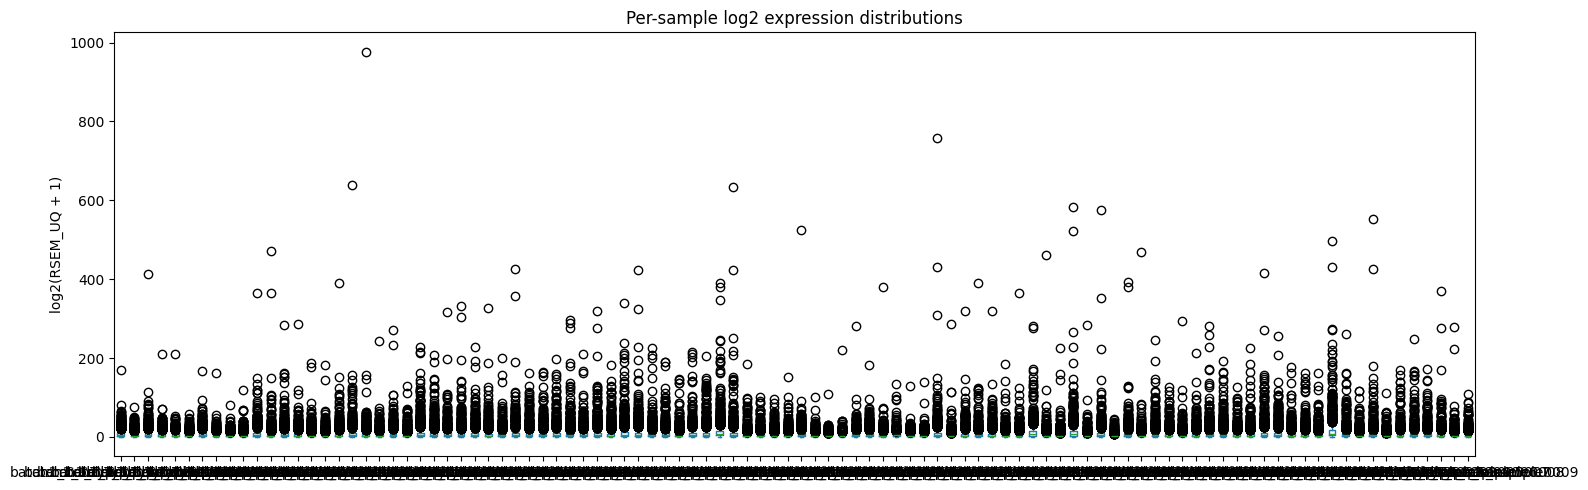

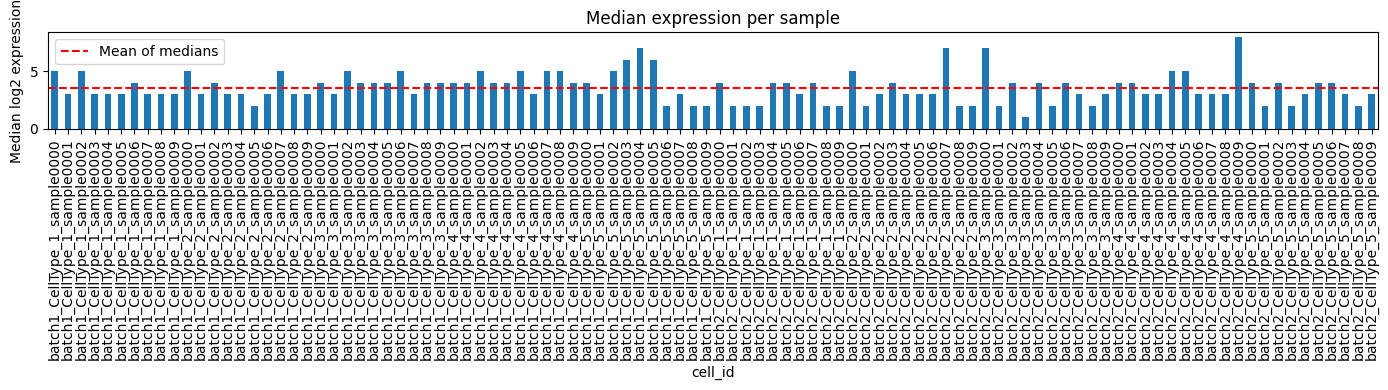

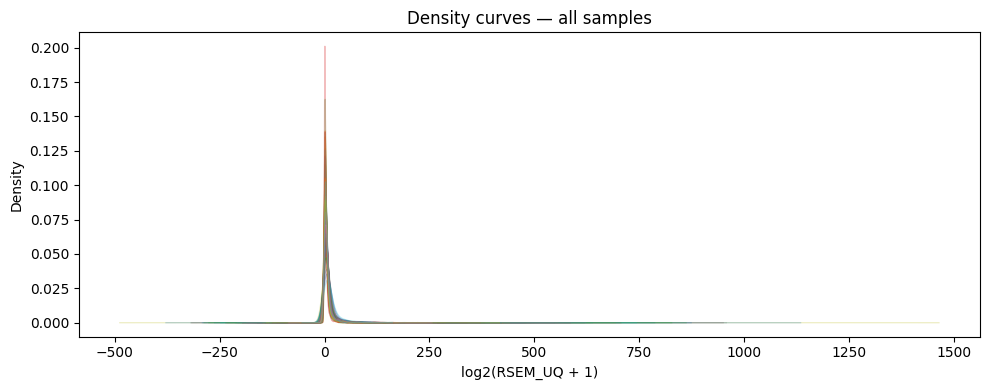

Genes with 0 in >50% of samples: 8


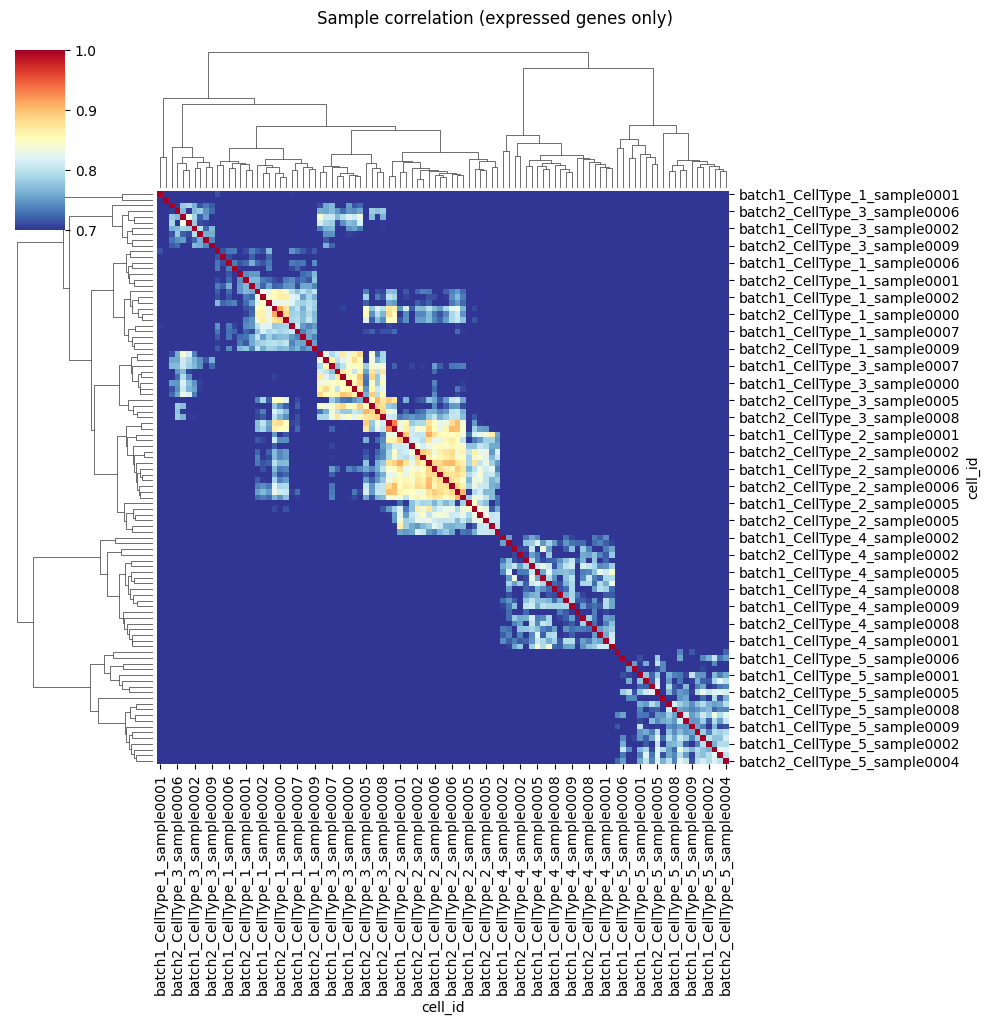

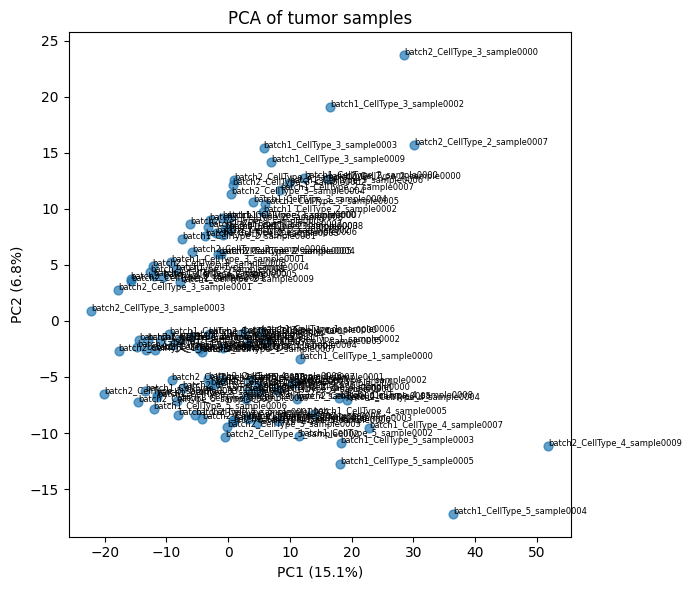

Global median: 3.0
Global IQR: 7.0
Samples with median < 1 (suspicious): 0


In [5]:
transcri_qc(rna_df.T)

Shape of the dataset:  (600, 100)
Value range: 8.74 to 19.36
Data type:  float32    100
Name: count, dtype: int64
Number of NaNs: 8048


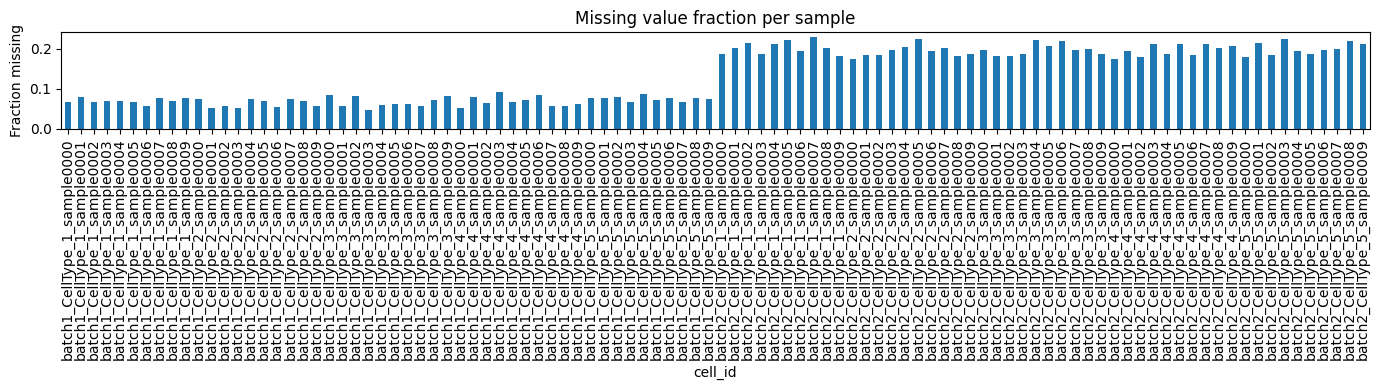

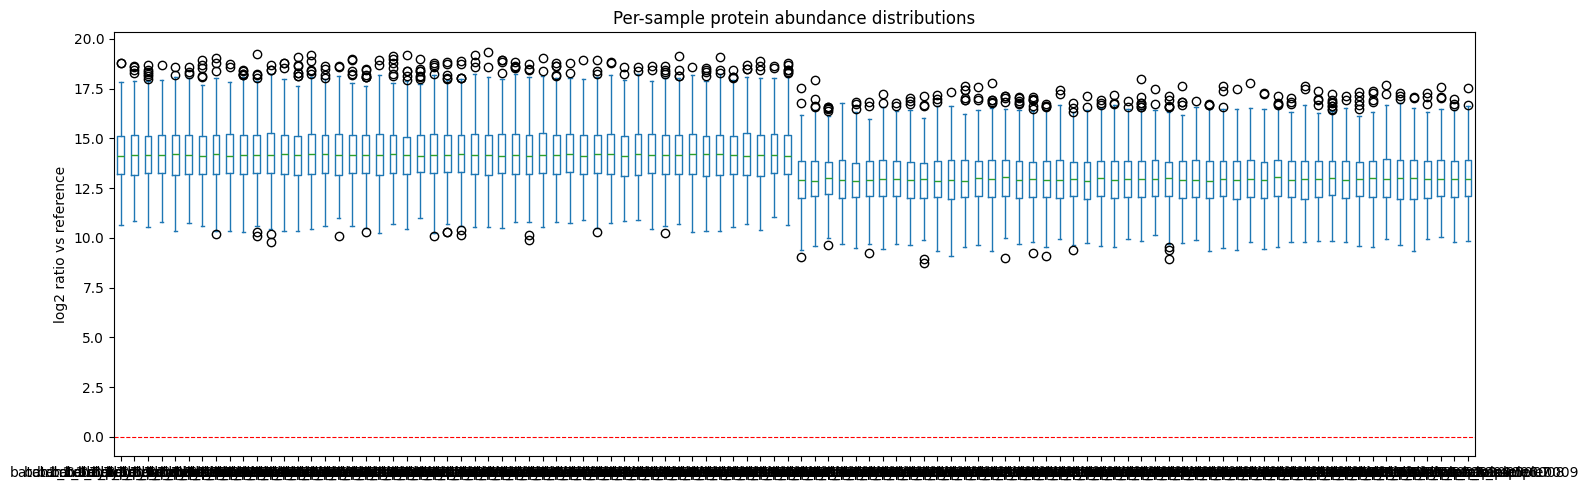

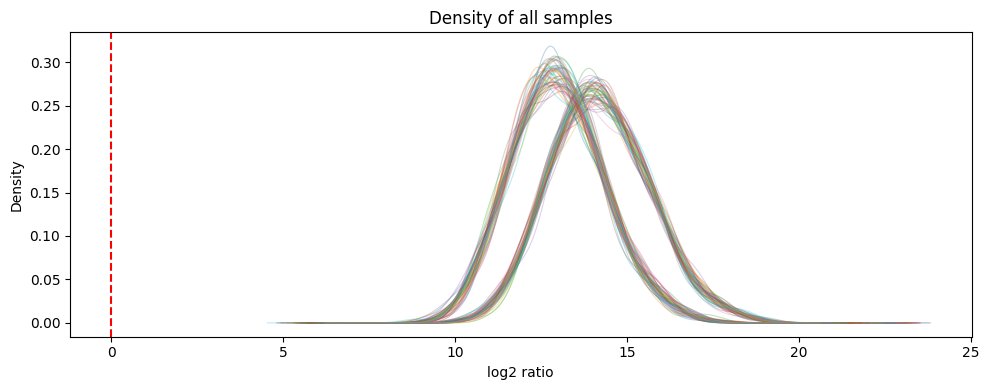

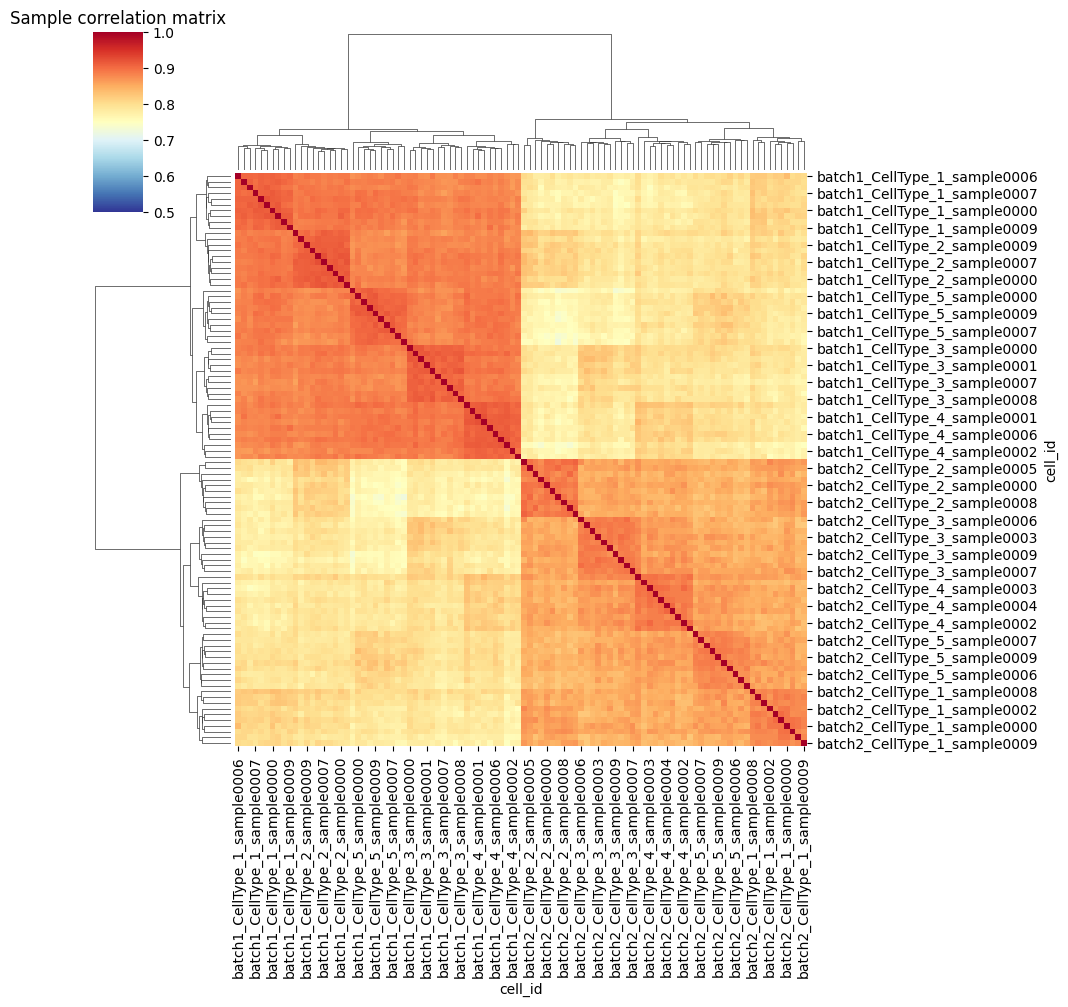

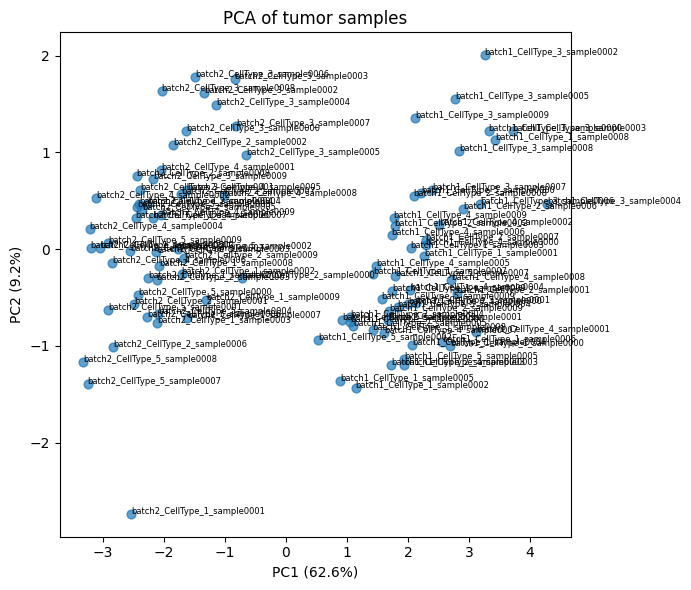

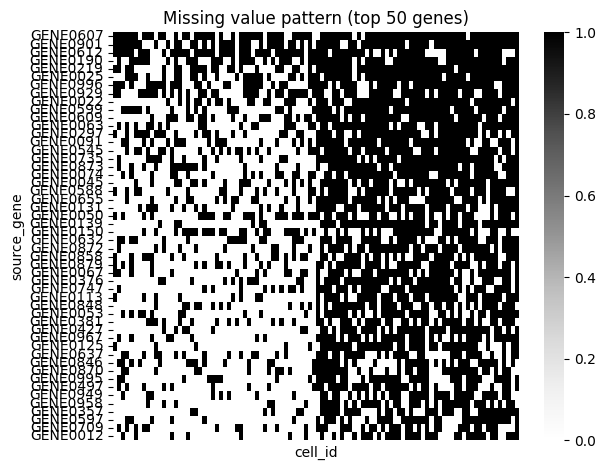

Global median: 13.584
Global IQR: 2.0665860176086426
Proteins with >50% missing: 22
Samples with >30% missing: 0


In [6]:
proteomics_qc(prot_df.T)

## Proteins preprocessing

Here, as an important batch effect is observed in the proteomic dataset, let us first correct this batch effect. Meanwhile, the missing data will also be inputed using the KNNImpute module, which has proven to get the best performances. 

In [7]:
#Getting proportion of missing values per sample
nan_positions=np.isnan(prot_df)
prop_nan=np.sum(nan_positions,axis=1)/nan_positions.shape[1]

Here, we impute the missing values with the values of their 5 nearest neighbours

In [8]:
## Removing missing values with KNN
prot_knn=prot_df.copy()
KNN=KNNImputer(missing_values=np.nan,         #placeholder for the missing values
               n_neighbors=5,              #number of neighboring samples to use
               weights='uniform',          #Weight function used in prediction.
               metric='nan_euclidean',     #Distance metric for searching neighbors
               copy=False,                 #imputation done in-place
               add_indicator=False,        #predictive estimator accounts for missingness despite imputation
               keep_empty_features=False)  #features that consist exclusively of missing values returned with value =0
KNN.fit_transform(prot_knn)
prot_knn

source_gene,GENE0001,GENE0002,GENE0003,GENE0004,GENE0005,GENE0006,GENE0007,GENE0008,GENE0009,GENE0010,...,GENE0978,GENE0980,GENE0981,GENE0984,GENE0985,GENE0993,GENE0995,GENE0996,GENE0997,GENE0998
cell_id,,,,,,,,,,,,,,,,,,,,,
batch1_CellType_1_sample0000,15.395514,14.179483,14.116085,14.157969,16.505259,14.513043,15.040704,16.220430,13.369759,13.490480,...,15.692969,14.537355,13.931174,14.547016,15.773411,14.335384,12.868075,11.404224,14.117914,13.403585
batch1_CellType_1_sample0001,14.655165,14.122156,14.673669,13.860523,17.157558,14.887857,15.367029,16.593422,13.354800,13.293138,...,15.069986,14.233890,12.454364,14.404501,15.192993,14.293482,12.706224,11.389288,14.155516,13.395632
batch1_CellType_1_sample0002,15.471313,12.750866,13.899436,13.343516,16.354969,14.230563,14.676167,16.254576,14.234394,13.227298,...,15.886830,15.361200,13.510928,14.168367,15.408723,13.753978,12.587810,11.338980,14.520604,13.292602
batch1_CellType_1_sample0003,14.719530,15.114807,14.139380,13.984716,16.704891,14.902282,14.754955,16.161562,13.564795,13.360991,...,15.474356,13.864791,13.687153,14.538136,15.784092,13.571823,11.822750,11.092446,14.385621,13.338772
batch1_CellType_1_sample0004,15.262705,14.076678,13.611950,13.669152,17.209587,14.902835,14.956245,16.089396,14.326101,13.088834,...,15.797982,14.600163,14.491558,14.312213,15.424625,14.255911,12.289118,11.293878,13.642570,13.432068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
batch2_CellType_5_sample0005,14.077635,13.062140,13.764499,11.709516,14.461390,13.033975,14.051123,14.033291,11.876596,11.319256,...,13.021938,12.725555,12.230124,13.600908,14.062998,12.351682,10.598711,10.385689,12.228260,11.591771
batch2_CellType_5_sample0006,13.839046,12.838821,13.516591,12.075836,13.752131,13.532655,13.499859,14.246455,12.873116,11.201846,...,12.770548,12.865991,12.189363,13.173529,13.004222,11.873837,10.430700,9.717429,12.572944,11.710806
batch2_CellType_5_sample0007,13.441296,12.752175,14.171851,12.131196,13.858584,13.330289,13.212894,14.095135,12.341082,11.206563,...,12.916662,13.725251,12.277160,13.570656,14.497766,11.522347,10.598711,9.953753,12.728573,11.866849


Then the batch effect is removed using combat norm. The module also normalises and further preprocesses our dataset.

In [9]:
# Removing batch effect using combat norm
prot_knn
prot_preprocessed=prot_knn.T

batch_vector = [col.split("_")[0] for col in prot_preprocessed.columns]
prot_preprocessed = pycombat_norm(prot_preprocessed, batch_vector)
    
prot_knn=prot_preprocessed

We finish with a quality check. The PCA and graphs are annotated based on the proportion of missing values in the samples, to ensure that the imputation doesn't add a specific patterning.

Shape of the dataset:  (600, 100)
Value range: 9.10 to 18.73
Data type:  float64    100
Name: count, dtype: int64
Number of NaNs: 0


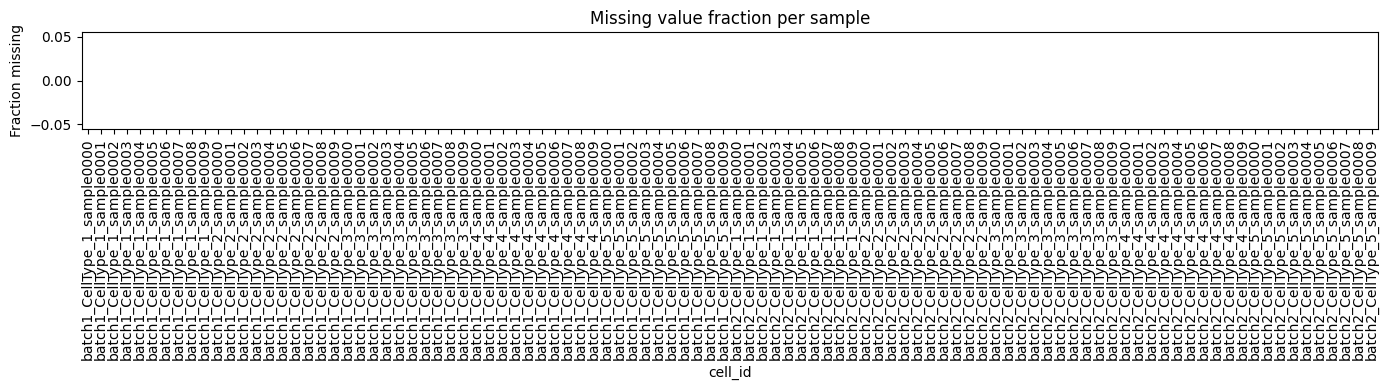

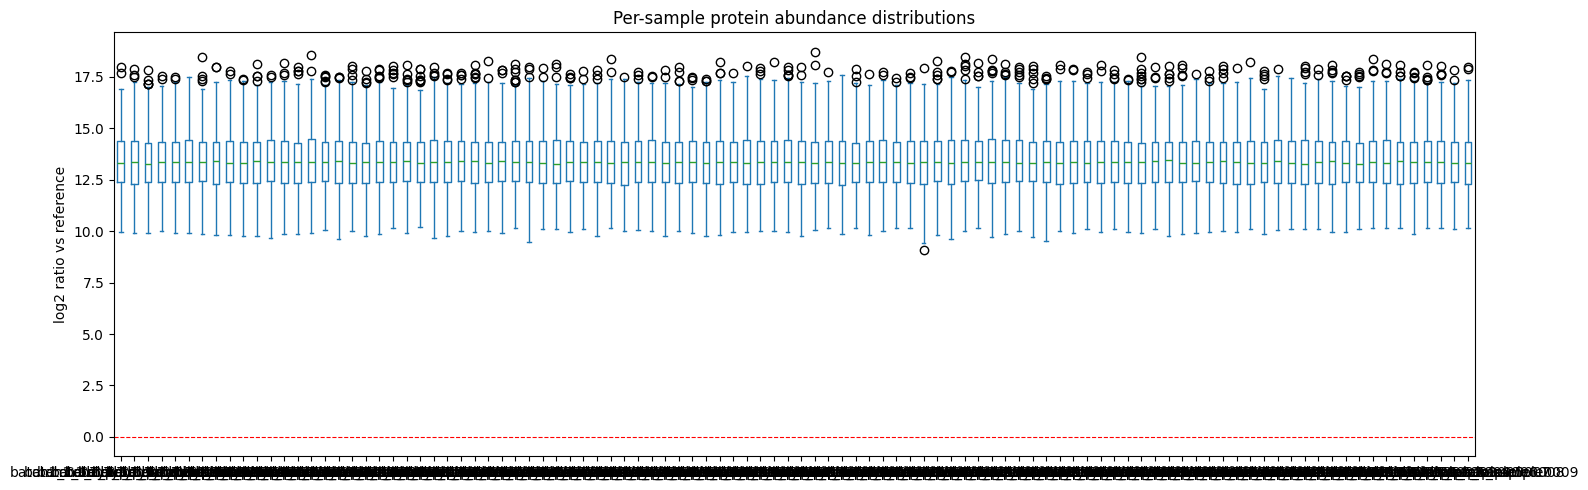

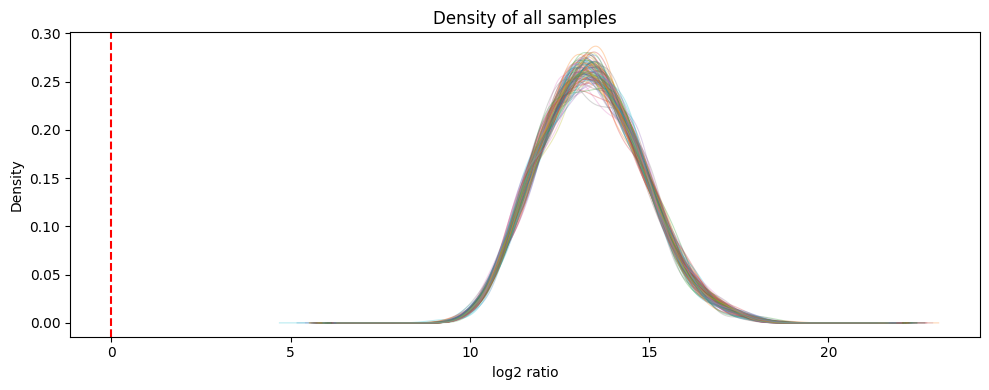

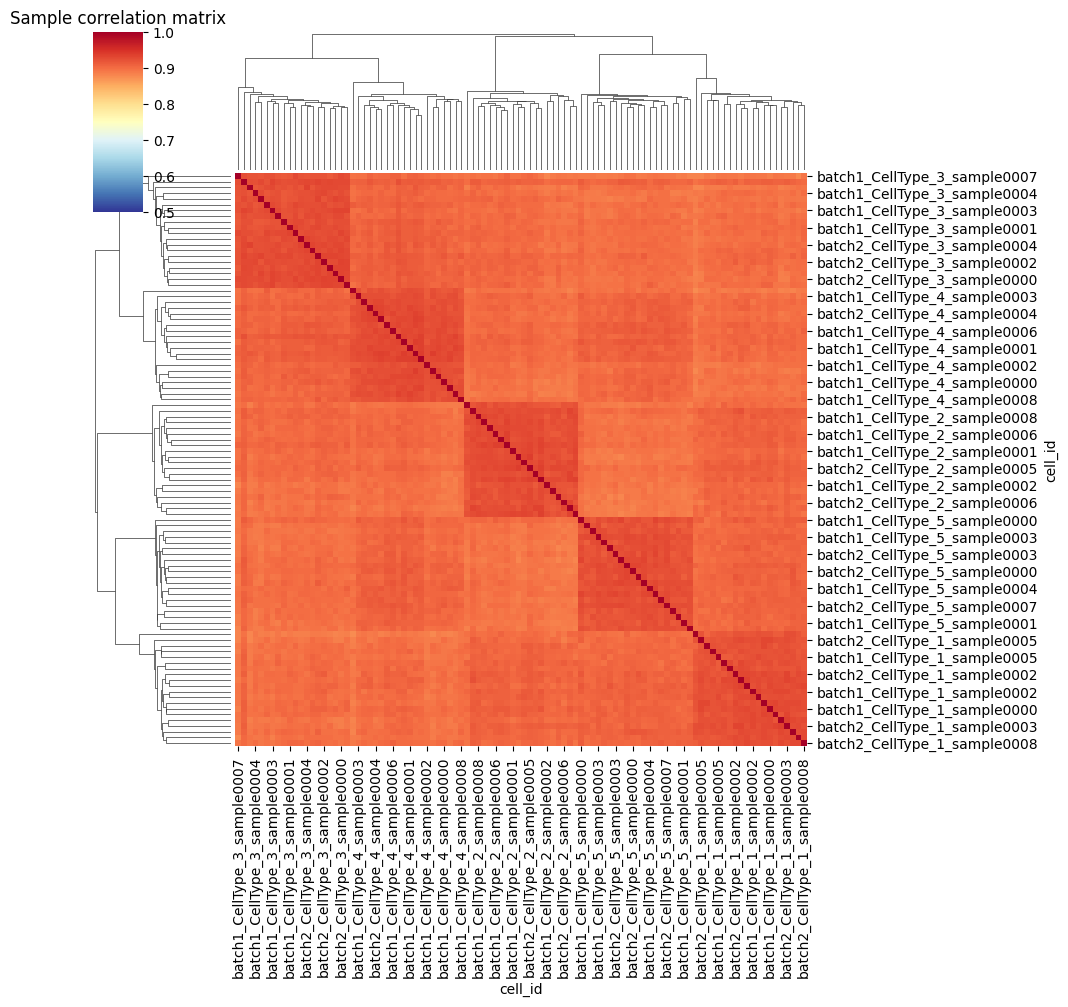

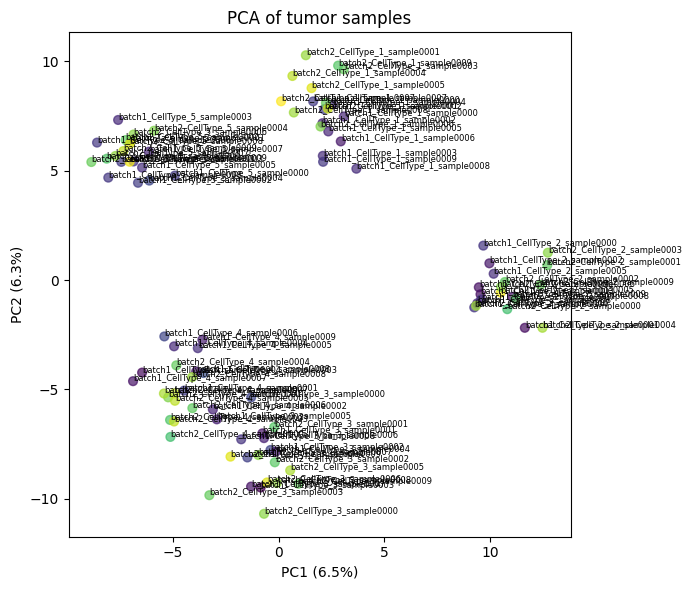

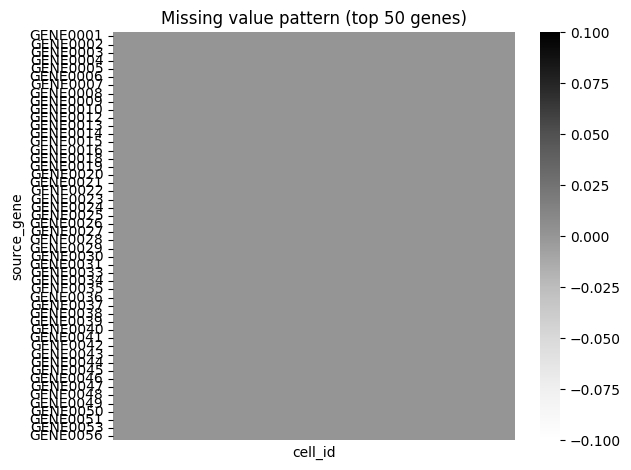

Global median: 13.354
Global IQR: 2.001405934017251
Proteins with >50% missing: 0
Samples with >30% missing: 0


In [10]:
proteomics_qc(prot_knn, color_pc=True, color_code=prop_nan)

As a final step, we retrieve the right orientation for our dataset (columns as genes, rows as samples).

In [11]:
## Final steps 
prot_knn=prot_knn.T  #getting the right orientation

## Transcriptomics preprocessing

Now, let us dive in the preprocessing of the RNA-seq dataset. Here, as no specific batch effect can be seen, and no missing data are found, the preprocessing is reduced to a filtering step. Since the data are bulk, we filter the genes with no expression in more than 50% of samples.

Shape of the dataset:  (987, 100)
Value range: 0.00 to 977.00
Number of zeros: 10695
Number of NaNs: 0


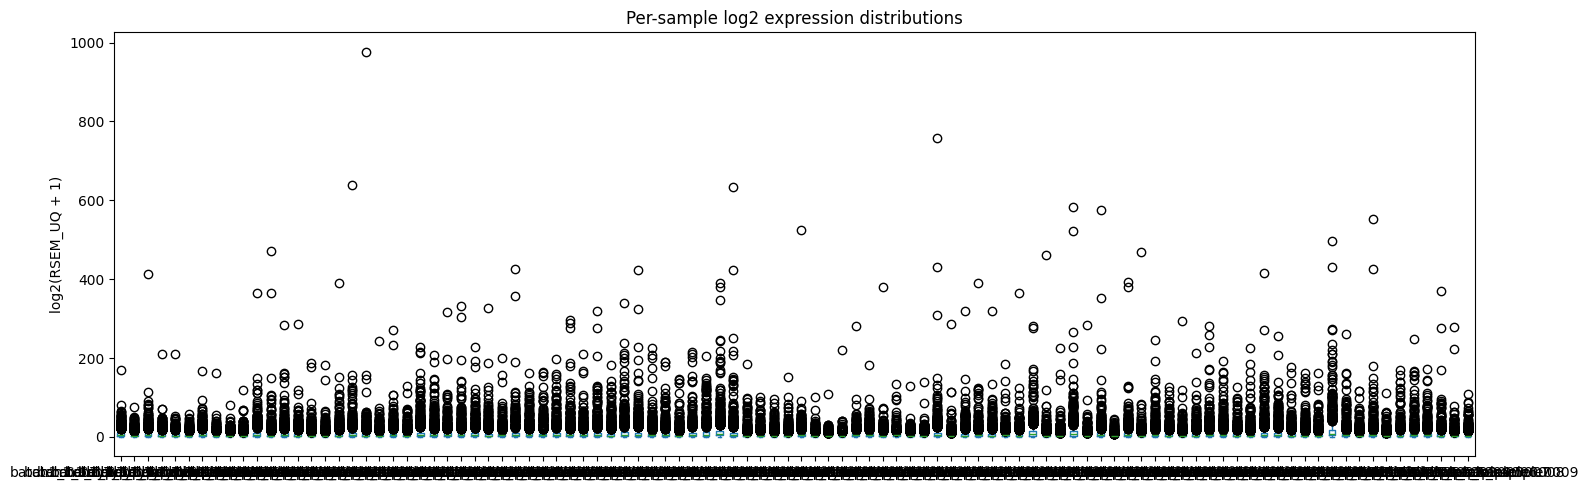

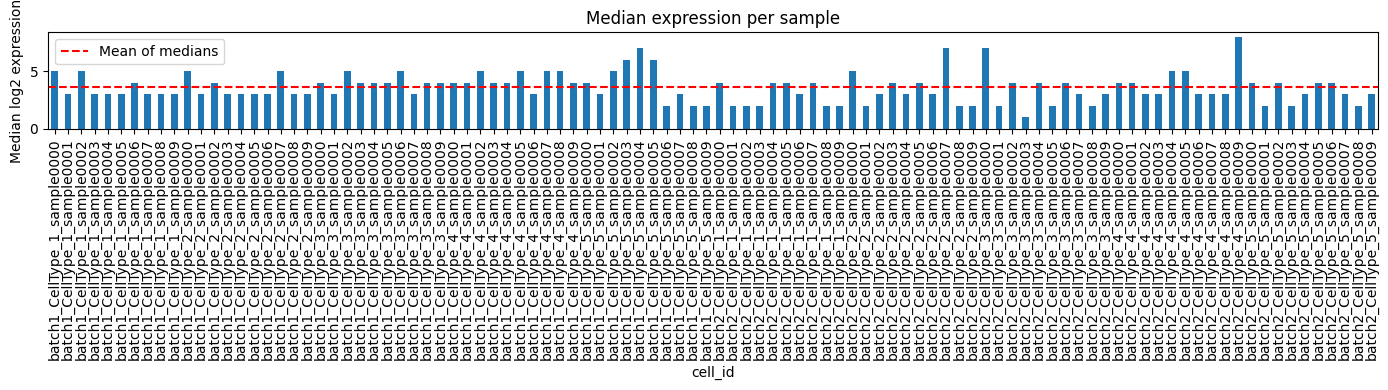

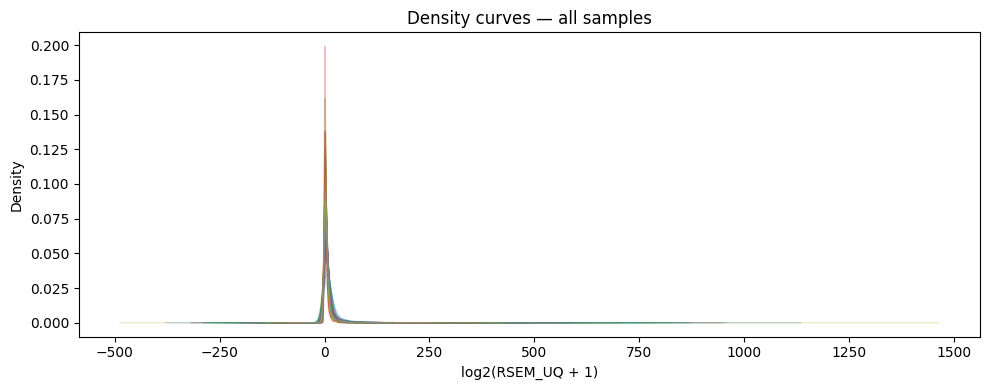

Genes with 0 in >50% of samples: 0


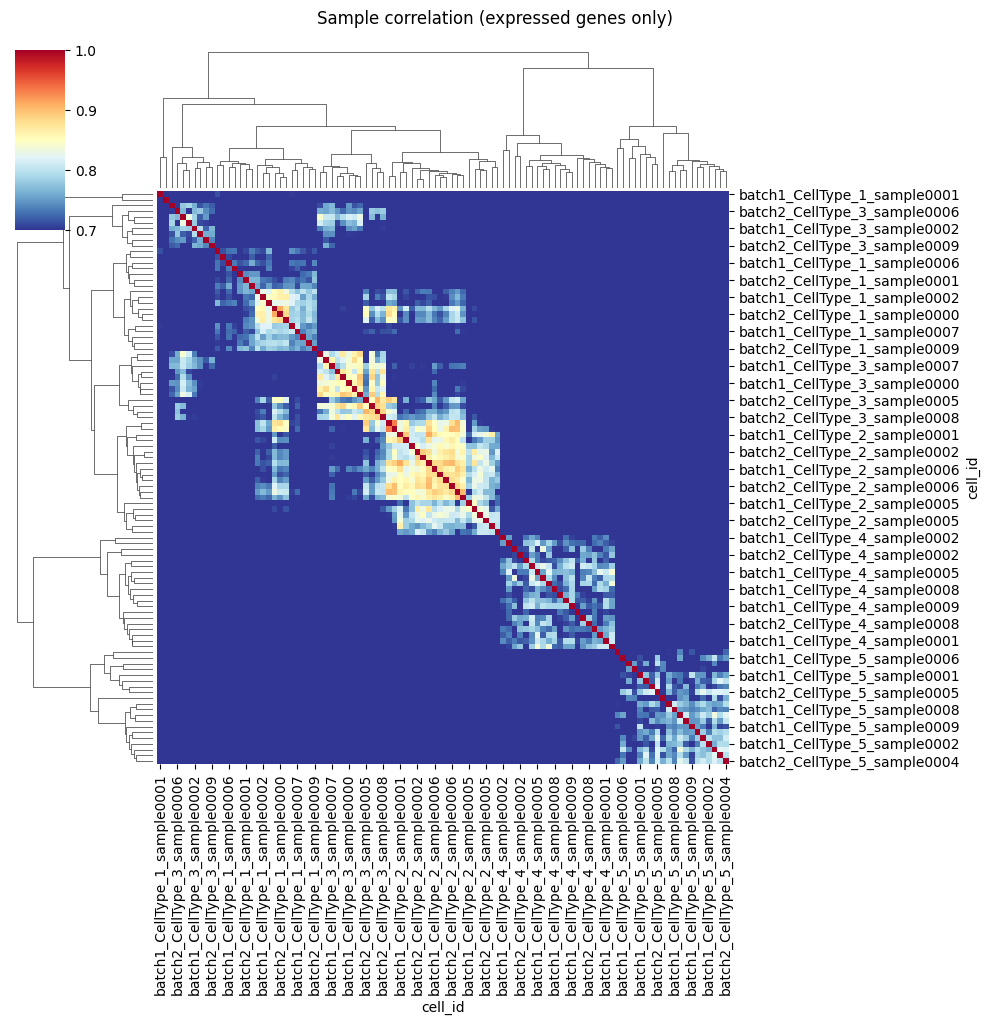

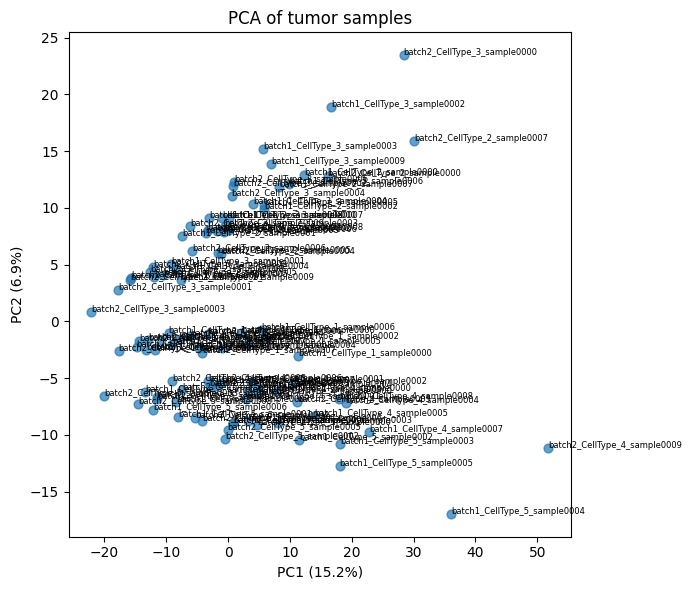

Global median: 3.0
Global IQR: 7.0
Samples with median < 1 (suspicious): 0


In [12]:
## Filtering low-expression genes (genes with no expression in more than 50% of samples)
rna_data=rna_df.T
zero_frac = (rna_data == 0).mean(axis=1)
filtered_rna_df=rna_data[zero_frac < 0.5].copy()
transcri_qc(filtered_rna_df)

We then perform a library-size normalisation, and log-transform the raw count matrix.

Shape of the dataset:  (987, 100)
Value range: 0.00 to 0.13
Number of zeros: 0
Number of NaNs: 0


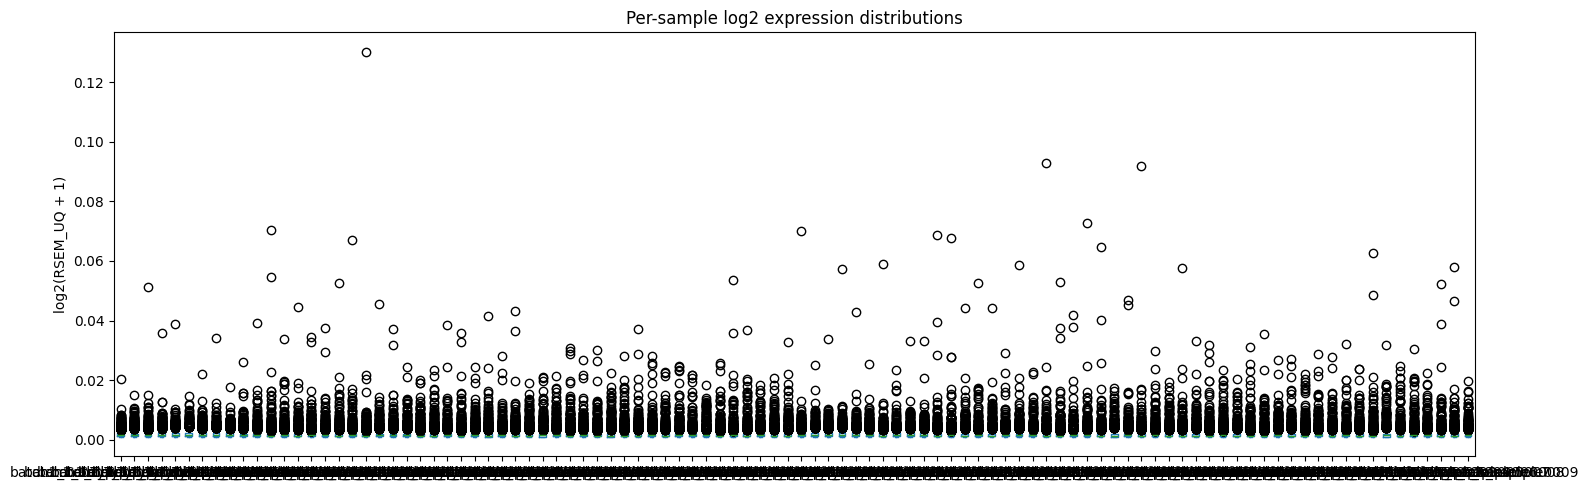

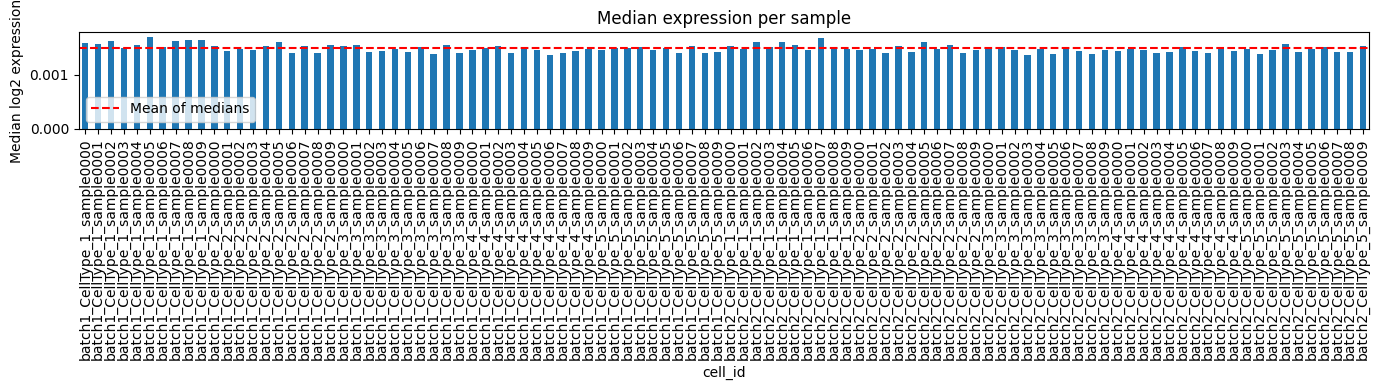

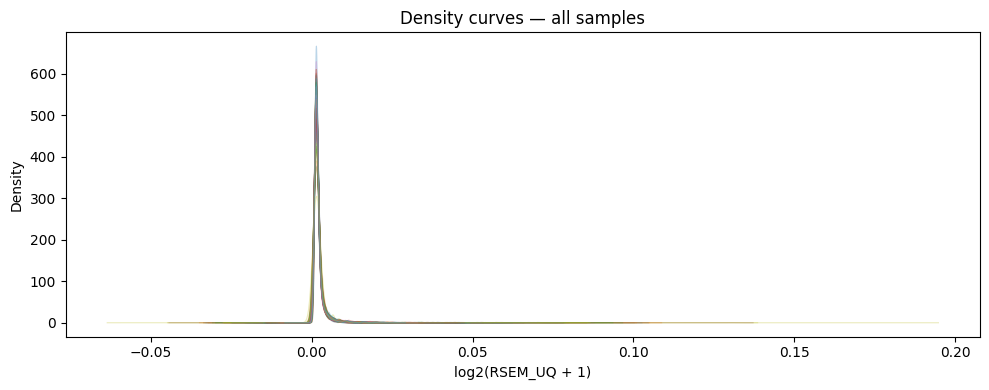

Genes with 0 in >50% of samples: 0


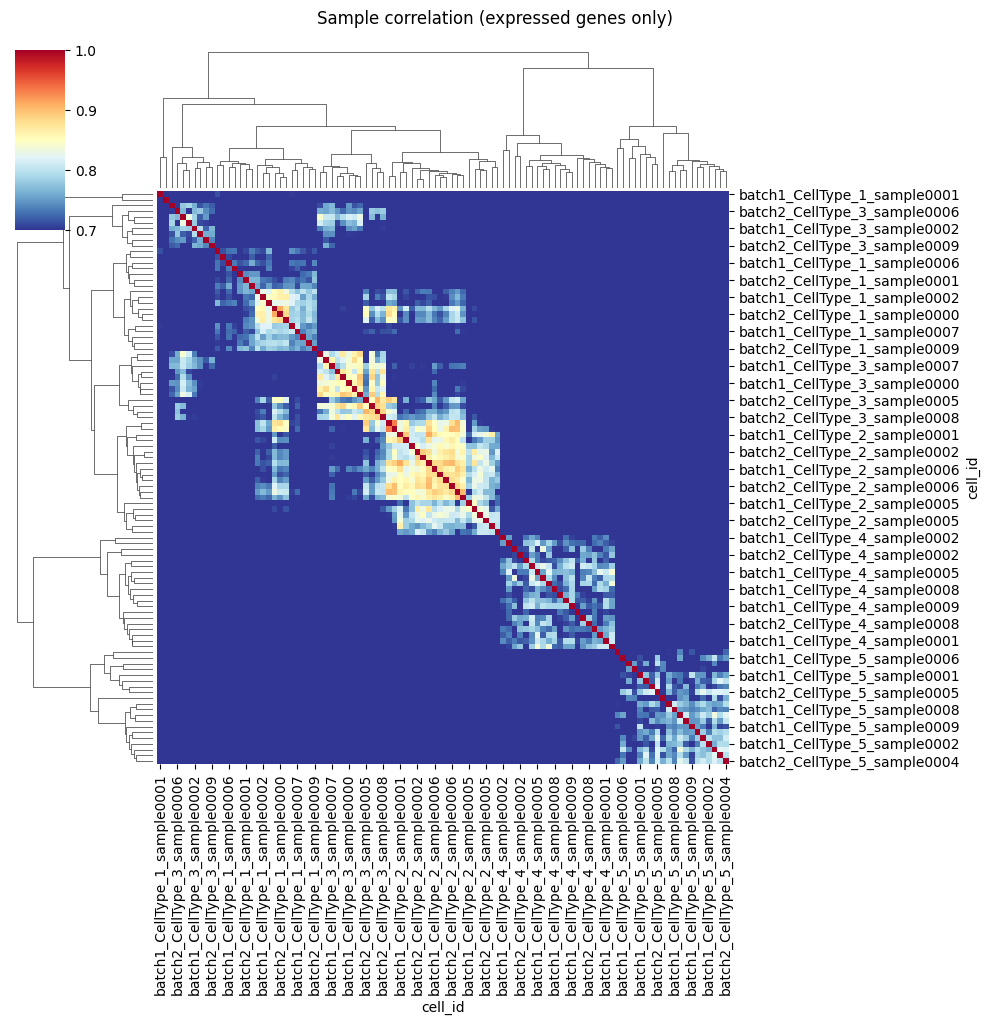

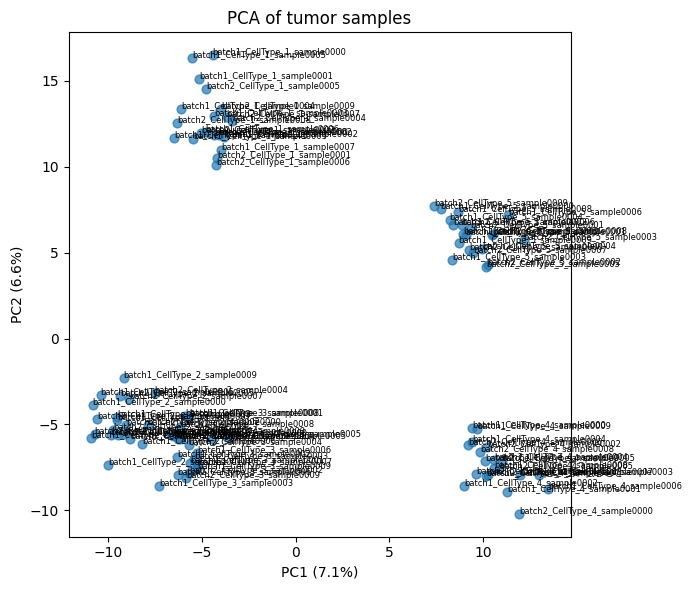

Global median: 0.001
Global IQR: 0.001
Samples with median < 1 (suspicious): 100


In [13]:
# Library size normalisation
lib_size=np.sum(filtered_rna_df, axis=0)
normalised_rna_df=filtered_rna_df/lib_size+0.001
transcri_qc(normalised_rna_df)

#Log-transforming
normalised_rna_df=np.log1p(normalised_rna_df)

To finalise, we ensure the right orientation of the matrix, similarly to what is done when preprocessing the proteomic dataset. 

In [14]:
#Getting the right orientation
normalised_rna_df=normalised_rna_df.T 

## Reformatting and saving dataset

Let us now save the dataset in the form of a mudata object, containing all the annotations, and ensuring that no issue arises. We also rename the columns. 

In [15]:
modalities=list(data.mod)
modalities

['rna', 'ms_prot']

In [16]:
# Rename columns with prefixes
rna_df_renamed  = normalised_rna_df.rename(columns=lambda c: f"rs_{c}")
prot_knn_renamed = prot_knn.rename(columns=lambda c: f"pp_{c}")

# Concatenate with a MultiIndex on rows (level 0 = data type, level 1 = cell obs)
combined_df_knn = pd.concat(
    {"rna": rna_df_renamed, "ms_prot": prot_knn_renamed},
    axis=1  # stack by rows
)

# Creating new mudata objects
combined_knn = multiindex_df_to_mudata_extended(combined_df_knn, feature_level=0, name_level=1, init_annot=data)
combined_knn

MuData object with n_obs × n_vars = 100 × 1587
  2 modalities
    rna:	100 x 987
      obs:	'cell_id', 'cell_type', 'batch'
      uns:	'active_pathways', 'inactive_pathways', 'pathway_rankings_per_cell_type', 'pathways', 'resolution'
      obsm:	'pathway_activity_truth', 'pathway_activity_truth_binary', 'pathway_activity_truth_ranked'
    ms_prot:	100 x 600
      obs:	'cell_id', 'cell_type', 'batch'
      var:	'source_gene', 'gene_index_in_rna', 'detectability_score'
      uns:	'data_type', 'missing_value', 'ms_mode', 'resolution'

Saving our mudata object, as well as csv files for the intermediate steps

In [17]:
#Saving
rna_df_renamed.to_csv("datasets/Simulation_dataset/simulated_transcriptomic_data_normalised_preprocessed.csv")
prot_knn_renamed.to_csv("datasets/Simulation_dataset/simulated_proteomic_data_normalised_preprocessed.csv")

combined_knn.write("datasets/Simulation_dataset/combined_simulatied_data_rna_and_prot_preprocessed.h5mu")

## Creating and saving matching gene set

As a last step, let us create and save a matching gene set. This gene set needs to integrate rna and proteomic data separately, as it will allow to differenciate the two modalities using multiROMA analysis.

In [18]:
from collections import defaultdict

#Specifying input and output files
gmt_input = "genesets/genesets_simulated_multiomics.gmt"
gmt_output = "genesets/genesets_simulated_multiomics_expanded.gmt"

# Get data genes (columns)
dataset_genes = combined_df_knn.columns.get_level_values(1)

#Buiding gene map : removing prefix, and gathering HGNC symbols
gene_map = defaultdict(list)

for g in dataset_genes:
    if "_" in g:
        prefix, gene = g.split("_", 1)
        gene_map[gene].append(g)

#Reading existing gmt
gene_sets = []

with open(gmt_input) as f:
    for line in f:
        parts = line.strip().split("\t")
        set_name = parts[0]
        description = parts[1]
        genes = parts[2:]
        gene_sets.append((set_name, description, genes))

#Creating the new set genes by matching existing genes and adding the right prefix
new_gene_sets = []

for set_name, description, genes in gene_sets:
    
    expanded_genes = []
    
    for gene in genes:
        if gene in gene_map:
            expanded_genes.extend(gene_map[gene])
    
    if expanded_genes:
        new_gene_sets.append(
            (set_name, description, expanded_genes)
        )

#Creating the new gene set
with open(gmt_output, "w") as f:
    for set_name, description, genes in new_gene_sets:
        line = "\t".join([set_name, description] + genes)
        f.write(line + "\n")

#new_gene_sets